# Part D — Deep Cox Model

Plots for **Part D — Deep Cox** (DeepSurv) of the IR&C Assignment 3 pipeline.

This notebook reads parquet outputs produced by `part_d_deep_cox.py` (and the
companion files from `part_c_ml_models.py`), all of which live in this folder
(`results_cd/`). It does no compute work beyond reshaping for plotting.

The plots answer four questions:
- **D(i)–(iii) sanity:** does the Deep Cox model train cleanly? Train/val loss curves.
- **D(v) ablation:** is the nonlinearity worth it? Linear-vs-Deep AUC/Brier/log-loss deltas.
- **D(iv) head-to-head:** how does Deep Cox compare with the classical Cox baseline (B) and the ML models from C (LogReg, RF, LightGBM)?
- **Where does it win or lose:** stratification by vintage and FICO.

**A note on framing.** The Cox partial likelihood is approximated per mini-batch
during Deep Cox training — risk sets are batch-local rather than global. This
is the standard pycox / DeepSurv approach and is documented in `D_model_meta.json`.
The reported AUC/Brier/log-loss are computed on the canonical test set
(vintages 2015–2019), held out from all training and tuning.


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "results_cd" else NB_DIR
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_curve, roc_auc_score

from utilities import (
    RESULTS_CD,
    HORIZONS,
    MODEL_ORDER,
    MODEL_COLORS,
    FICO_BUCKETS,
    VINTAGE_BUCKETS,
    apply_plot_style,
    read_target_mode,
)

apply_plot_style()

TARGET_MODE = read_target_mode()
print(f"Target mode (from results_cd/target_mode.txt): {TARGET_MODE!r}")


Target mode (from results_cd/target_mode.txt): 'cause_specific'


## Load data

Part D files (mandatory) and Part C files (optional, used for the
head-to-head). If Part C didn't write predictions/metrics, the notebook
still renders D-only views without crashing.

In [2]:
# ----- Part D outputs (required) -----
predictions = pd.read_parquet(RESULTS_CD / "D_predictions.parquet")
metrics = pd.read_parquet(RESULTS_CD / "D_metrics.parquet")

# Calibration / training history / ablation / meta are not strictly required
# but practically always present.
def _opt_read(path: Path) -> pd.DataFrame | None:
    return pd.read_parquet(path) if path.exists() else None

calibration_d   = _opt_read(RESULTS_CD / "D_calibration.parquet")
history         = _opt_read(RESULTS_CD / "D_training_history.parquet")
ablation        = _opt_read(RESULTS_CD / "D_linear_vs_deep.parquet")
meta_path       = RESULTS_CD / "D_model_meta.json"
meta            = json.loads(meta_path.read_text()) if meta_path.exists() else {}

# ----- Part C outputs (optional) -----
c_pred_path = RESULTS_CD / "C_predictions.parquet"
c_metr_path = RESULTS_CD / "C_metrics.parquet"
c_calb_path = RESULTS_CD / "C_calibration.parquet"

if c_pred_path.exists():
    predictions_c = pd.read_parquet(c_pred_path)
    metrics_c     = _opt_read(c_metr_path)
    calibration_c = _opt_read(c_calb_path)

    # Sanity: rows should align by LoanSequenceNumber.
    assert len(predictions_c) == len(predictions), (
        f"Row-count mismatch: C={len(predictions_c)} D={len(predictions)}. "
        f"Re-run Part C and Part D with the same --drop-vintage-year and "
        f"--target-mode flags."
    )
    if not (predictions_c["LoanSequenceNumber"].values
            == predictions["LoanSequenceNumber"].values).all():
        # If row order differs, merge on the join key explicitly.
        c_cols = ["LoanSequenceNumber"] + [c for c in predictions_c.columns
                                            if c.startswith("pred_")]
        predictions = predictions.merge(predictions_c[c_cols],
                                         on="LoanSequenceNumber", how="left")
    else:
        for col in predictions_c.columns:
            if col.startswith("pred_") and col not in predictions.columns:
                predictions[col] = predictions_c[col].values

    if metrics_c is not None:
        metrics = pd.concat([metrics_c, metrics], ignore_index=True)
    if calibration_c is not None and calibration_d is not None:
        calibration = pd.concat([calibration_c, calibration_d], ignore_index=True)
    elif calibration_c is not None:
        calibration = calibration_c
    else:
        calibration = calibration_d
else:
    print("WARNING: C_predictions.parquet not found in results_cd/. "
          "Plots will show Part D models only.")
    calibration = calibration_d

# Identify which models actually have predictions.
models_present = []
for m in MODEL_ORDER:
    cols = [f"pred_{m}_T{T}" for T in HORIZONS]
    if all(c in predictions.columns for c in cols):
        # Accept the model even if some columns are all-NaN (e.g. Cox
        # didn't converge); plotting code defensively skips empty preds.
        models_present.append(m)

print("Models present:", models_present)
print()
print(f"Predictions:        {len(predictions):,} rows, {predictions.shape[1]} cols")
print(f"Metrics:            {len(metrics):,} rows")
if calibration is not None:
    print(f"Calibration:        {len(calibration):,} rows")
if history is not None:
    print(f"Training history:   {len(history):,} rows")
if ablation is not None:
    print(f"D(v) ablation:      {len(ablation):,} rows")


Models present: ['LogReg', 'RF', 'LGBM', 'Cox', 'LinearCox', 'DeepCox']

Predictions:        597,205 rows, 37 cols
Metrics:            288 rows
Calibration:        240 rows
Training history:   60 rows
D(v) ablation:      4 rows


## D(i)–(iii) sanity — training history

Train and validation loss per epoch for both the Deep model and the
Linear baseline. Validation loss is also the early-stopping signal —
a smooth, monotone-then-plateau val-loss curve indicates clean training;
a sharply rising val curve indicates overfitting and would have triggered
the patience-based early stop.

The loss is the **negative partial log-likelihood per minibatch** (the
pycox CoxPH default), so smaller is better but absolute values aren't
directly interpretable as probabilities.

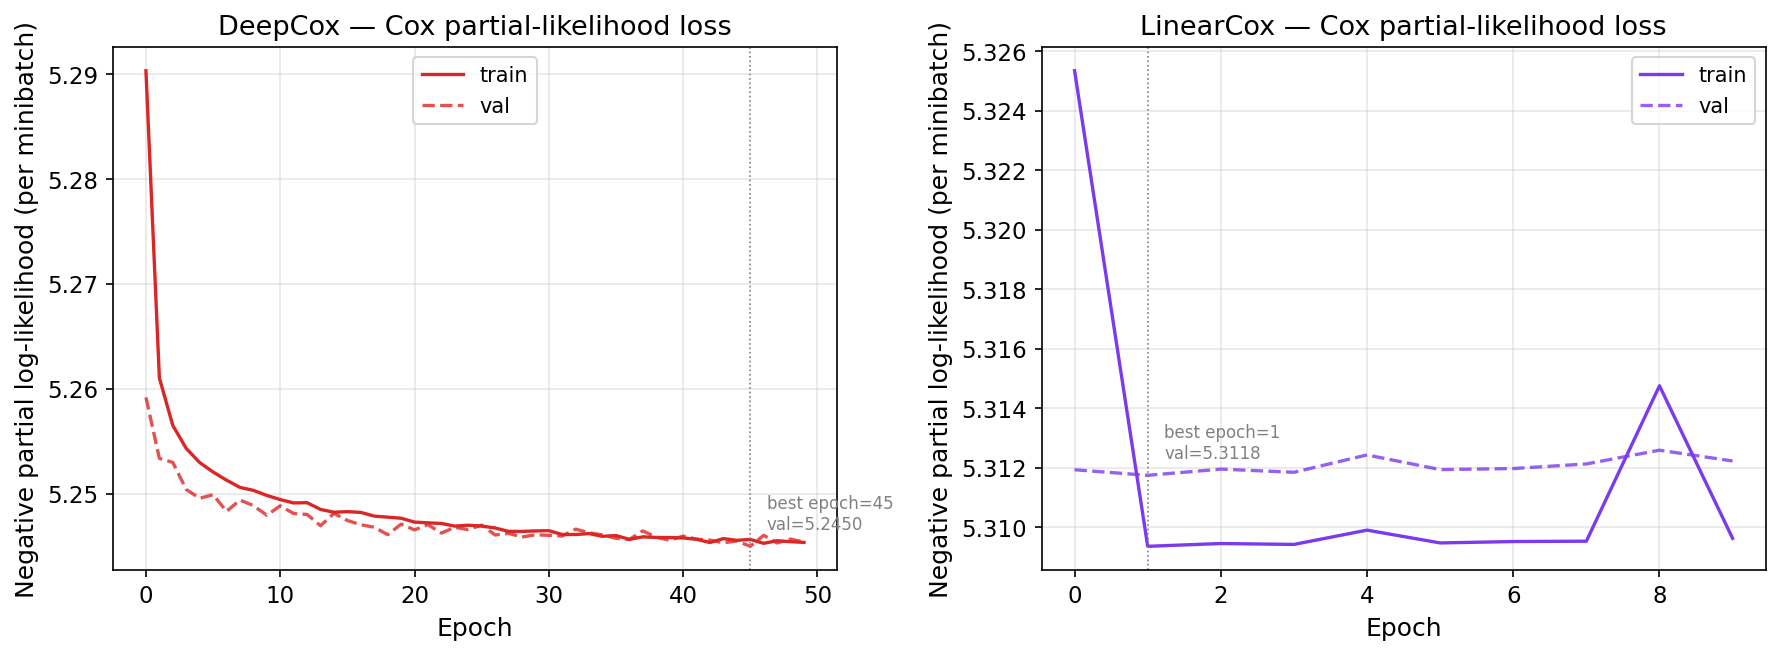

In [3]:
def plot_training_history(history):
    if history is None or len(history) == 0:
        print("No training history to plot.")
        return

    models_in_hist = list(history["model"].unique())
    fig, axes = plt.subplots(1, len(models_in_hist),
                             figsize=(6 * len(models_in_hist), 4.5),
                             squeeze=False)
    axes = axes.ravel()
    for ax, m in zip(axes, models_in_hist):
        sub = history[history["model"] == m].sort_values("epoch")
        x = sub["epoch"].values
        if "train_loss" in sub.columns:
            ax.plot(x, sub["train_loss"], "-",
                    color=MODEL_COLORS.get(m, "C0"), label="train",
                    linewidth=1.6)
        if "val_loss" in sub.columns:
            ax.plot(x, sub["val_loss"], "--",
                    color=MODEL_COLORS.get(m, "C0"), label="val",
                    linewidth=1.6, alpha=0.8)
        # Mark best (min val) epoch
        if "val_loss" in sub.columns and sub["val_loss"].notna().any():
            best_idx = sub["val_loss"].idxmin()
            best_epoch = int(sub.loc[best_idx, "epoch"])
            best_val = float(sub.loc[best_idx, "val_loss"])
            ax.axvline(best_epoch, color="gray", linestyle=":", linewidth=0.8)
            ax.annotate(f"best epoch={best_epoch}\nval={best_val:.4f}",
                        xy=(best_epoch, best_val),
                        xytext=(8, 8), textcoords="offset points",
                        fontsize=8, color="gray")
        ax.set_title(f"{m} — Cox partial-likelihood loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Negative partial log-likelihood (per minibatch)")
        ax.legend()
    fig.tight_layout()
    plt.show()

plot_training_history(history)


## D(v) — Linear-vs-Deep ablation

The Deep model has 3 hidden layers of 64 units; the Linear baseline is
the same architecture with **zero hidden layers** — i.e. it is functionally
a re-implementation of classical Cox via gradient descent + Breslow.

If nonlinearities matter for prepayment, **`auc_delta` should be positive**
across horizons (the Sadhwani et al. 2021 paper documents this for
the broader prime/subprime universe). If not, the Cox PH linear
specification is essentially adequate for this dataset.

`brier_delta` and `logloss_delta` are *negative* when Deep is better
(lower Brier / log-loss → better calibration / sharper predictions).

In [4]:
def show_ablation_table(ablation):
    if ablation is None or len(ablation) == 0:
        print("No ablation data found.")
        return
    cols = ["horizon", "auc_deep", "auc_linear", "auc_delta",
            "brier_deep", "brier_linear", "brier_delta",
            "logloss_deep", "logloss_linear", "logloss_delta",
            "n", "n_events"]
    cols = [c for c in cols if c in ablation.columns]
    print(ablation[cols].round(4).to_string(index=False))

show_ablation_table(ablation)


 horizon  auc_deep  auc_linear  auc_delta  brier_deep  brier_linear  brier_delta  logloss_deep  logloss_linear  logloss_delta      n  n_events
      12    0.6837      0.6807     0.0030      0.0925        0.0935      -0.0010        0.3240          0.3289        -0.0050 596352     64105
      24    0.7007      0.6738     0.0269      0.1885        0.1986      -0.0101        0.5588          0.5855        -0.0267 595508    171452
      36    0.7211      0.6772     0.0439      0.2186        0.2419      -0.0233        0.6269          0.6786        -0.0517 591019    258447
      60    0.7292      0.6848     0.0445      0.2007        0.2479      -0.0473        0.5866          0.6886        -0.1020 531898    381377


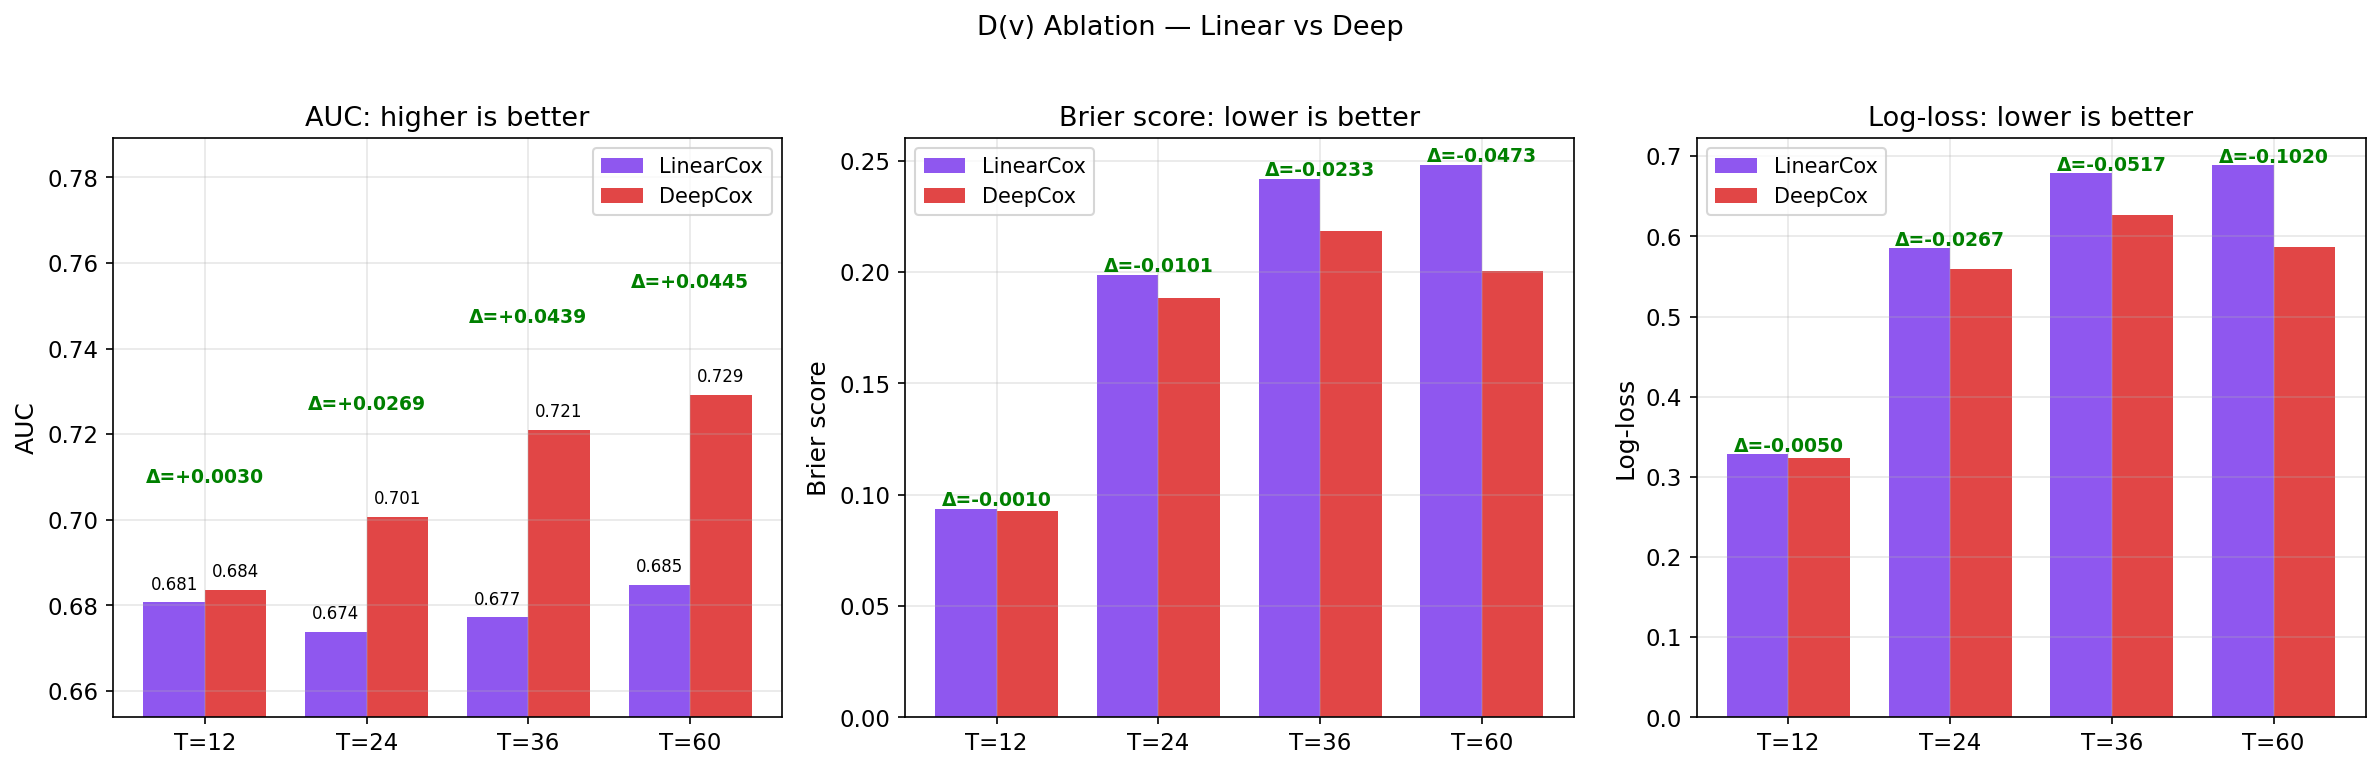

In [5]:
def plot_ablation(ablation):
    if ablation is None or len(ablation) == 0:
        return
    horizons = sorted(ablation["horizon"].unique())
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    width = 0.38
    x = np.arange(len(horizons))

    # AUC: higher is better
    ax = axes[0]
    deep = [float(ablation.loc[ablation.horizon == T, "auc_deep"].iloc[0])
            for T in horizons]
    lin  = [float(ablation.loc[ablation.horizon == T, "auc_linear"].iloc[0])
            for T in horizons]
    ax.bar(x - width/2, lin,  width, label="LinearCox",
            color=MODEL_COLORS["LinearCox"], alpha=0.85)
    ax.bar(x + width/2, deep, width, label="DeepCox",
            color=MODEL_COLORS["DeepCox"], alpha=0.85)
    for i, (l, d) in enumerate(zip(lin, deep)):
        ax.text(i - width/2, l + 0.003, f"{l:.3f}", ha="center", fontsize=8)
        ax.text(i + width/2, d + 0.003, f"{d:.3f}", ha="center", fontsize=8)
        delta = d - l
        ax.text(i, max(l, d) + 0.025, f"Δ={delta:+.4f}",
                ha="center", fontsize=9, fontweight="bold",
                color="green" if delta > 0 else "red")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in horizons])
    ax.set_ylabel("AUC")
    ax.set_title("AUC: higher is better")
    ax.set_ylim(min(min(lin), min(deep)) - 0.02,
                max(max(lin), max(deep)) + 0.06)
    ax.legend()

    # Brier: lower is better
    ax = axes[1]
    deep = [float(ablation.loc[ablation.horizon == T, "brier_deep"].iloc[0])
            for T in horizons]
    lin  = [float(ablation.loc[ablation.horizon == T, "brier_linear"].iloc[0])
            for T in horizons]
    ax.bar(x - width/2, lin,  width, label="LinearCox",
            color=MODEL_COLORS["LinearCox"], alpha=0.85)
    ax.bar(x + width/2, deep, width, label="DeepCox",
            color=MODEL_COLORS["DeepCox"], alpha=0.85)
    for i, (l, d) in enumerate(zip(lin, deep)):
        delta = d - l
        ax.text(i, max(l, d) + 0.0015, f"Δ={delta:+.4f}",
                ha="center", fontsize=9, fontweight="bold",
                color="green" if delta < 0 else "red")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in horizons])
    ax.set_ylabel("Brier score")
    ax.set_title("Brier score: lower is better")
    ax.legend()

    # Log-loss: lower is better
    ax = axes[2]
    deep = [float(ablation.loc[ablation.horizon == T, "logloss_deep"].iloc[0])
            for T in horizons]
    lin  = [float(ablation.loc[ablation.horizon == T, "logloss_linear"].iloc[0])
            for T in horizons]
    ax.bar(x - width/2, lin,  width, label="LinearCox",
            color=MODEL_COLORS["LinearCox"], alpha=0.85)
    ax.bar(x + width/2, deep, width, label="DeepCox",
            color=MODEL_COLORS["DeepCox"], alpha=0.85)
    for i, (l, d) in enumerate(zip(lin, deep)):
        delta = d - l
        ax.text(i, max(l, d) + 0.003, f"Δ={delta:+.4f}",
                ha="center", fontsize=9, fontweight="bold",
                color="green" if delta < 0 else "red")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in horizons])
    ax.set_ylabel("Log-loss")
    ax.set_title("Log-loss: lower is better")
    ax.legend()

    fig.suptitle("D(v) Ablation — Linear vs Deep", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

plot_ablation(ablation)


## D(iv) head-to-head — AUC by horizon

All models on one canvas: the three ML models from Part C
(LogReg, RF, LightGBM), the classical Cox baseline (also from C, fit via
lifelines), the depth-0 LinearCox baseline (D(v)), and the Deep Cox model.

If DeepCox dominates the others, that's evidence for nonlinear interactions
beyond what tree models can find via axis-aligned splits and beyond what
classical Cox can find with its single linear predictor. If RF / LightGBM
are competitive with DeepCox, the dataset's nonlinear structure is already
captured by tree splits.

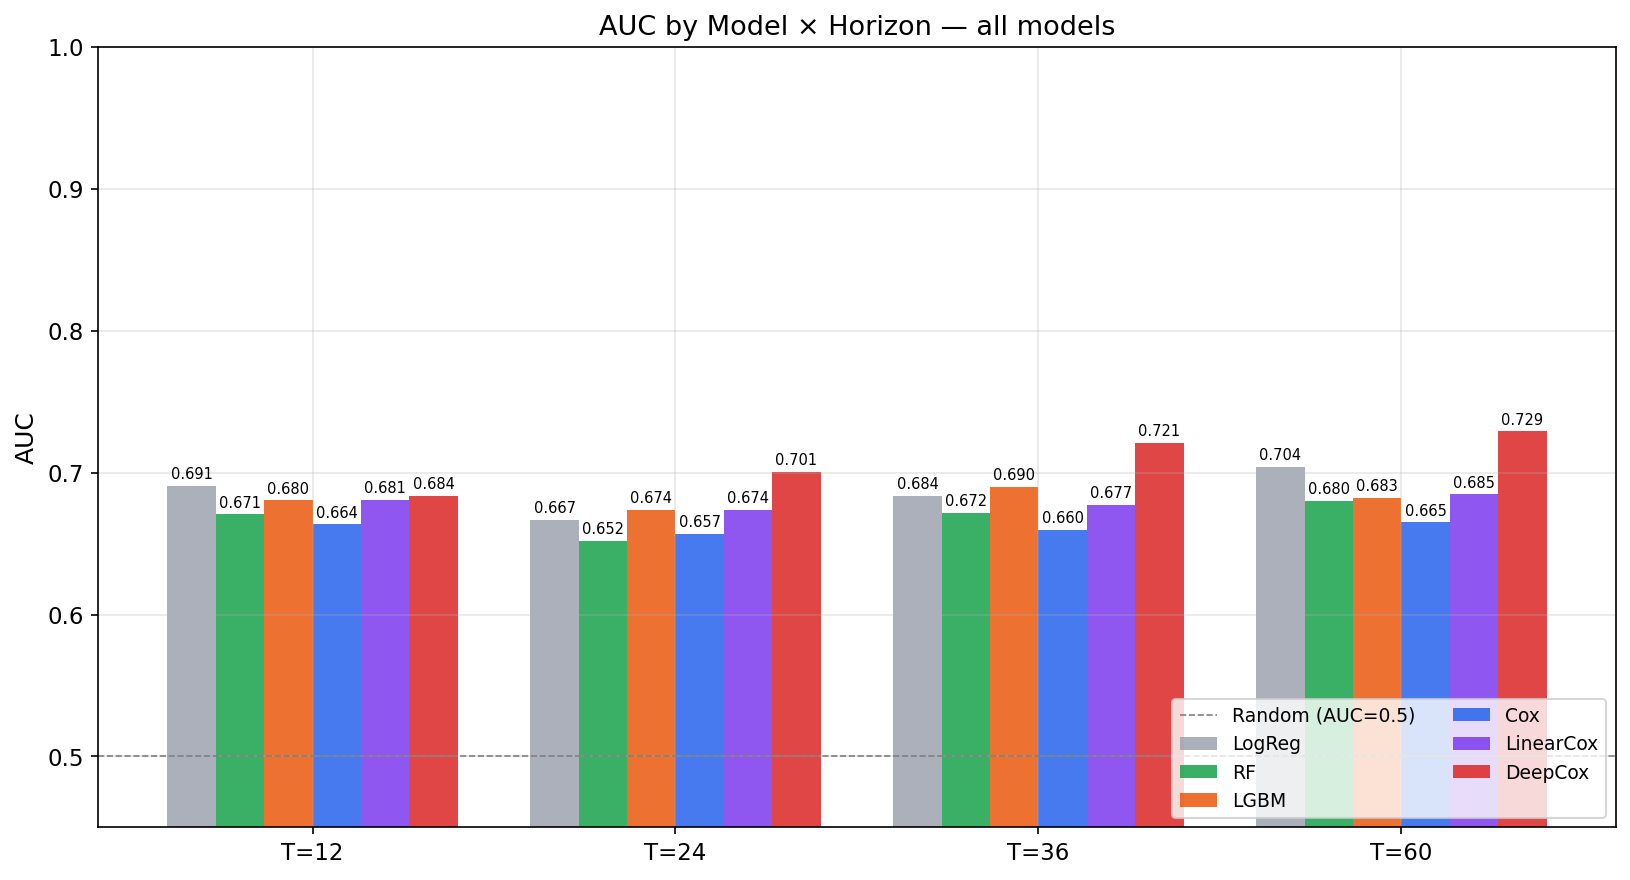

AUC by model × horizon:
horizon        12      24      36      60
model                                    
LogReg     0.6908  0.6670  0.6837  0.7043
RF         0.6706  0.6519  0.6718  0.6803
LGBM       0.6805  0.6738  0.6899  0.6825
Cox        0.6635  0.6571  0.6596  0.6650
LinearCox  0.6807  0.6738  0.6772  0.6848
DeepCox    0.6837  0.7007  0.7211  0.7292


In [6]:
def plot_auc_by_horizon(metrics, models):
    overall = metrics[metrics["stratum_type"] == "all"].copy()
    fig, ax = plt.subplots(figsize=(11, 6))
    width = 0.8 / max(len(models), 1)
    x = np.arange(len(HORIZONS))
    for i, m in enumerate(models):
        sub = overall[overall["model"] == m].set_index("horizon")
        if sub.empty:
            continue
        aucs = [sub.loc[T, "auc"] if T in sub.index else np.nan
                for T in HORIZONS]
        offset = (i - (len(models) - 1) / 2) * width
        ax.bar(x + offset, aucs, width, color=MODEL_COLORS.get(m, "C0"),
                label=m, alpha=0.85)
        for j, v in enumerate(aucs):
            if pd.notna(v):
                ax.text(x[j] + offset, v + 0.005, f"{v:.3f}",
                        ha="center", fontsize=7, rotation=0)
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in HORIZONS])
    ax.set_ylabel("AUC")
    ax.set_title("AUC by Model × Horizon — all models")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8,
                label="Random (AUC=0.5)")
    ax.legend(loc="lower right", ncol=2, fontsize=9)
    ax.set_ylim(0.45, 1.0)
    fig.tight_layout()
    plt.show()

plot_auc_by_horizon(metrics, models_present)

# Print the table too
overall = metrics[metrics["stratum_type"] == "all"].copy()
if len(overall):
    print("AUC by model × horizon:")
    print(overall.pivot_table(
        index="model", columns="horizon", values="auc", aggfunc="first",
    ).reindex([m for m in MODEL_ORDER if m in models_present])
       .round(4).to_string())


## ROC curves by horizon — all models

ROC overlays for every model at every horizon. With six models the plot
gets busy — the legend is sorted by AUC descending so the top performer
is the first colored line.

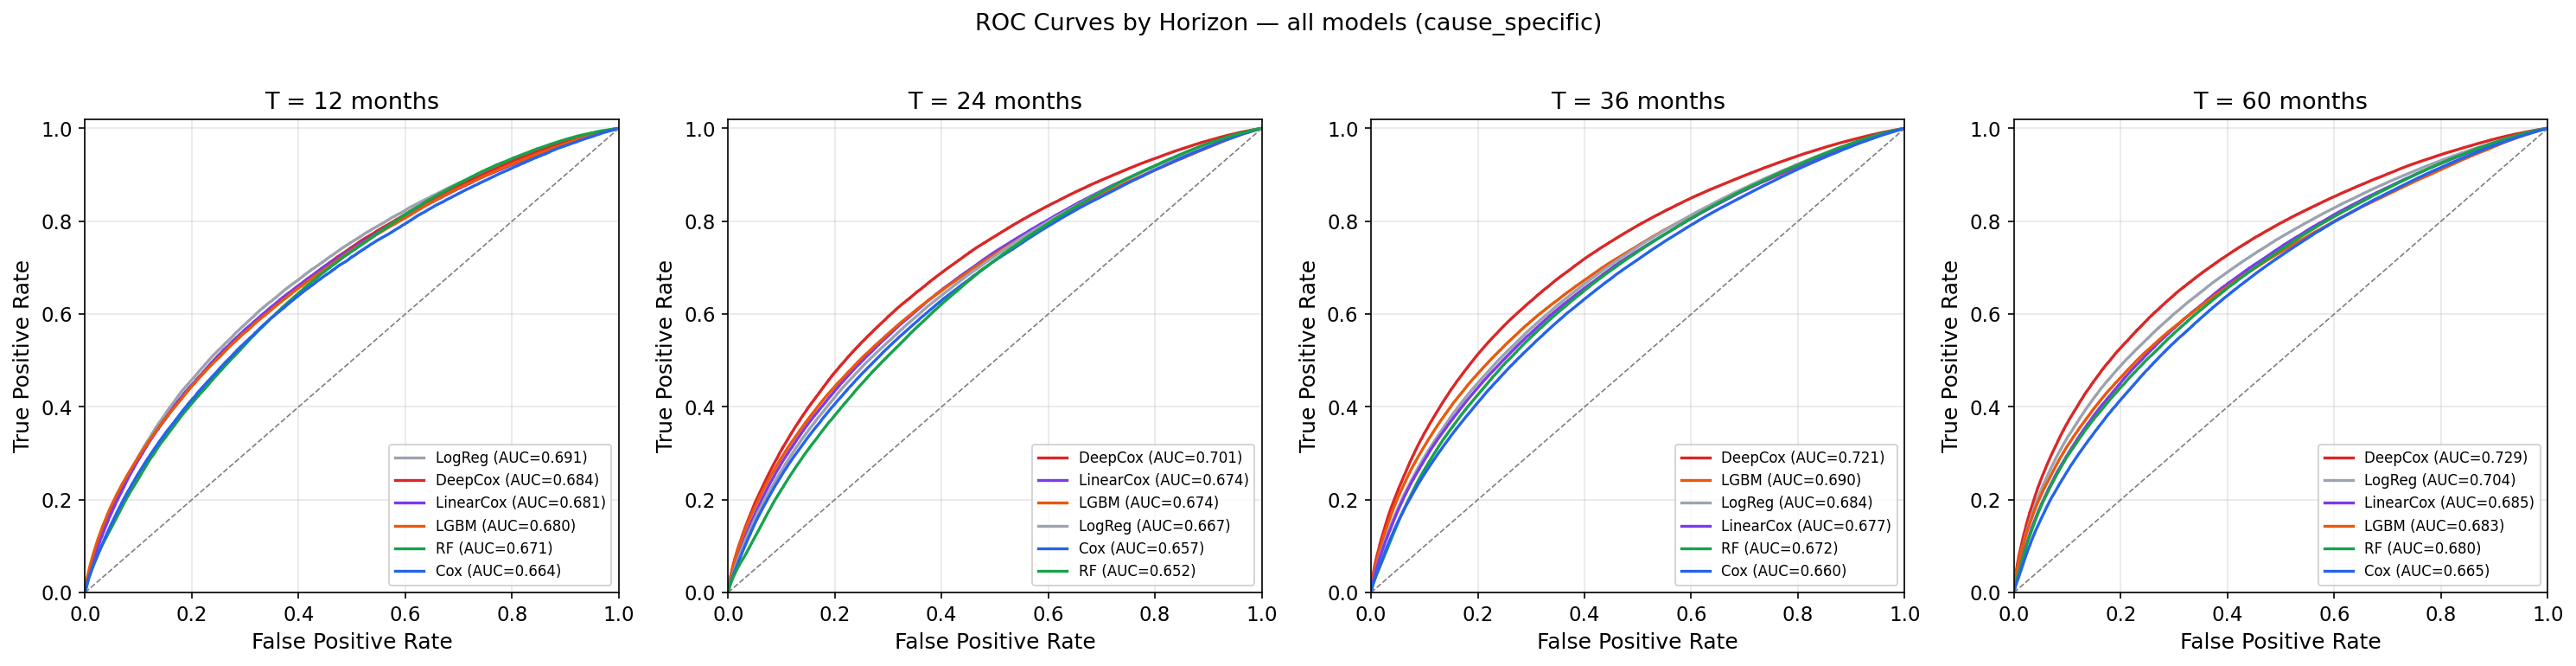

In [7]:
def plot_roc_curves(preds, models, mode_label):
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, T in zip(axes, HORIZONS):
        target = preds[f"Target_T{T}"]
        valid_target = target.notna()
        # Compute AUCs first so we can sort the legend
        aucs = {}
        rocs = {}
        for m in models:
            pcol = f"pred_{m}_T{T}"
            if pcol not in preds.columns:
                continue
            valid = valid_target & preds[pcol].notna()
            if valid.sum() < 100:
                continue
            y = target[valid].astype(int).values
            p = preds.loc[valid, pcol].values
            if len(np.unique(y)) < 2:
                continue
            fpr, tpr, _ = roc_curve(y, p)
            aucs[m] = roc_auc_score(y, p)
            rocs[m] = (fpr, tpr)
        # Sort by AUC descending so the legend reads top-to-bottom
        for m in sorted(aucs, key=aucs.get, reverse=True):
            fpr, tpr = rocs[m]
            ax.plot(fpr, tpr, color=MODEL_COLORS.get(m, "C0"),
                    linewidth=1.6, label=f"{m} (AUC={aucs[m]:.3f})")
        ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"T = {T} months")
        ax.legend(loc="lower right", fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
    fig.suptitle(f"ROC Curves by Horizon — all models ({mode_label})",
                 fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

plot_roc_curves(predictions, models_present, TARGET_MODE)


## Brier score & log-loss

Brier and log-loss don't only reflect rank quality (like AUC); they also
penalize miscalibration. A model can have high AUC but bad Brier if its
probability scale is off — useful diagnostic.

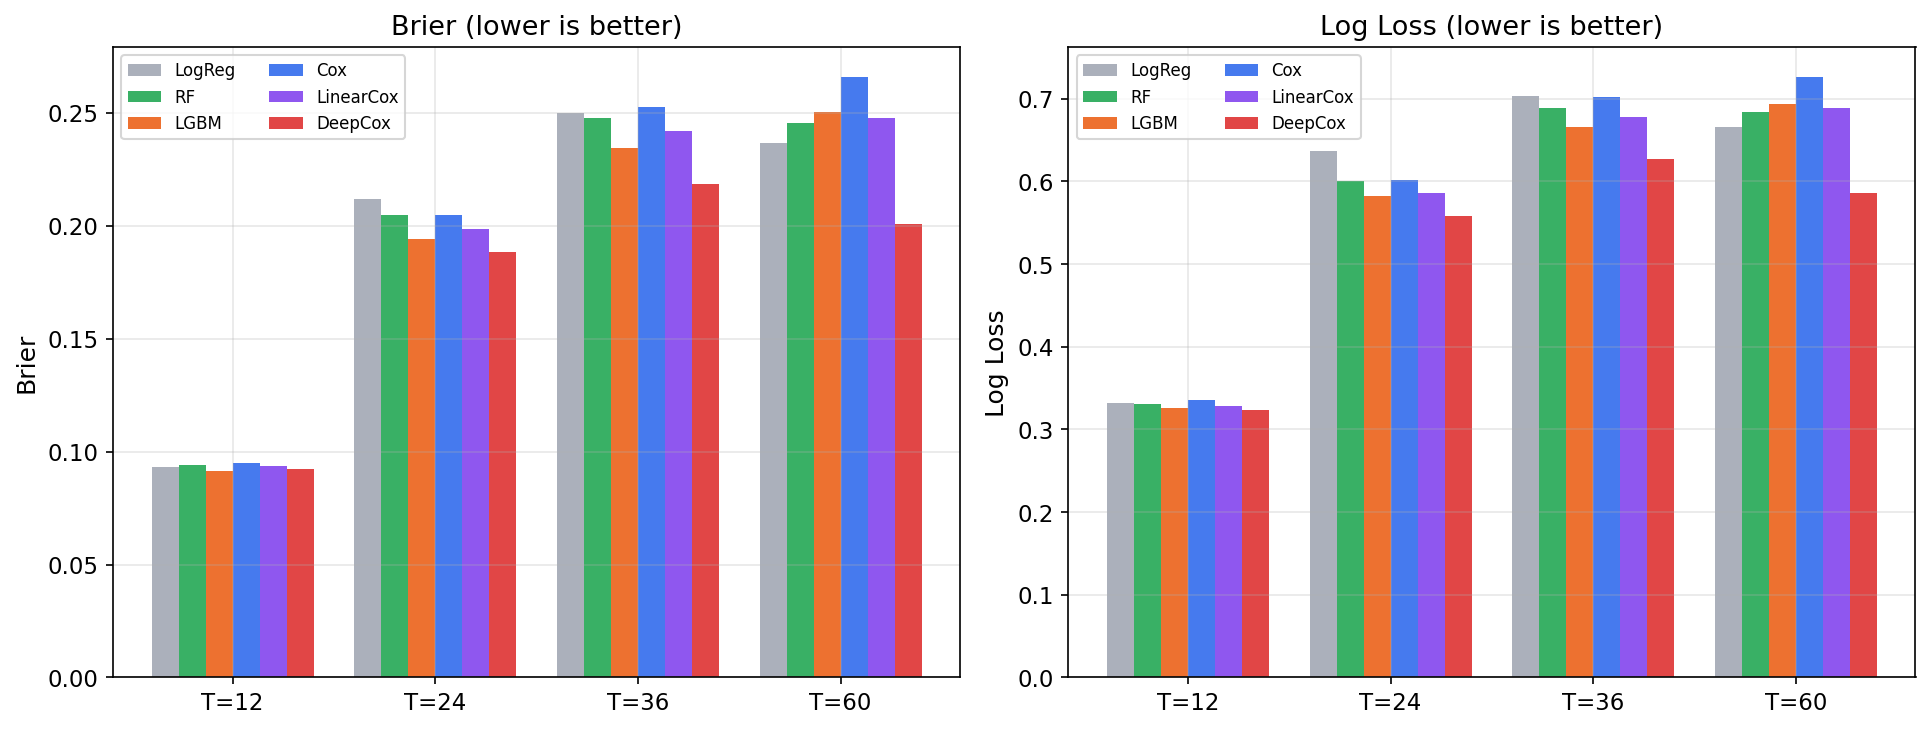

In [8]:
def plot_metrics_summary(metrics, models, metric_cols=("brier", "log_loss")):
    overall = metrics[metrics["stratum_type"] == "all"].copy()
    fig, axes = plt.subplots(1, len(metric_cols),
                              figsize=(6.5 * len(metric_cols), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, mc in zip(axes, metric_cols):
        width = 0.8 / max(len(models), 1)
        x = np.arange(len(HORIZONS))
        for i, m in enumerate(models):
            sub = overall[overall["model"] == m].set_index("horizon")
            if sub.empty or mc not in sub.columns:
                continue
            vals = [sub.loc[T, mc] if T in sub.index else np.nan
                    for T in HORIZONS]
            offset = (i - (len(models) - 1) / 2) * width
            ax.bar(x + offset, vals, width, color=MODEL_COLORS.get(m, "C0"),
                    label=m, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([f"T={T}" for T in HORIZONS])
        ax.set_ylabel(mc.replace("_", " ").title())
        ax.set_title(f"{mc.replace('_', ' ').title()} (lower is better)")
        ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

plot_metrics_summary(metrics, models_present)


## Calibration — predicted vs observed prepayment rate

Decile reliability plot. Each model's predictions are sorted into 10
equal-mass bins; the x-axis shows the average predicted probability in
each bin and the y-axis shows the empirical prepayment rate in that bin.
Perfect calibration lies on the diagonal.

Tree-based models (RF, LightGBM) are typically well-calibrated when given
enough samples per leaf; logistic-regression-style models (LogReg, the
Cox-derived predictions) can be miscalibrated because their probability
scale isn't directly fit to the binary outcome.

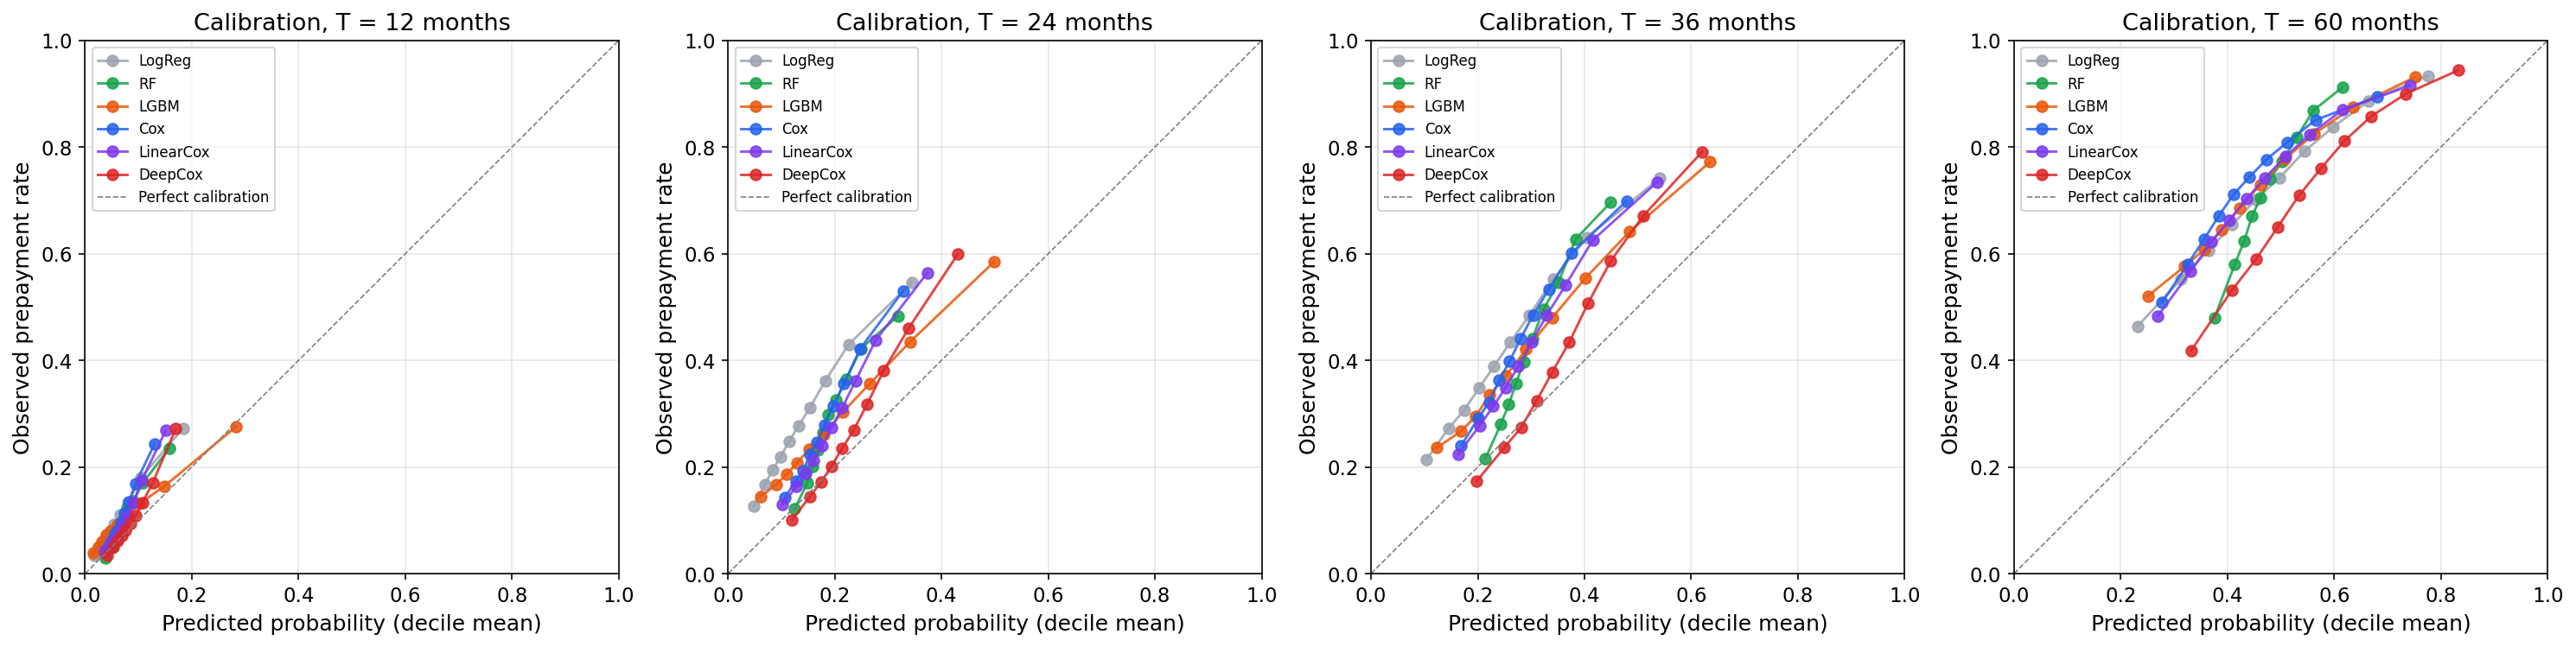

In [9]:
def plot_calibration(calib, models):
    if calib is None or len(calib) == 0:
        print("No calibration data found.")
        return
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, T in zip(axes, HORIZONS):
        for m in models:
            sub = calib[(calib["model"] == m) & (calib["horizon"] == T)]
            if sub.empty:
                continue
            ax.plot(sub["pred_mean"], sub["observed_rate"], "o-",
                    color=MODEL_COLORS.get(m, "C0"), linewidth=1.4,
                    markersize=6, label=m, alpha=0.85)
        ax.plot([0, 1], [0, 1], "--", color="gray",
                linewidth=0.8, label="Perfect calibration")
        ax.set_xlabel("Predicted probability (decile mean)")
        ax.set_ylabel("Observed prepayment rate")
        ax.set_title(f"Calibration, T = {T} months")
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    plt.show()

plot_calibration(calibration, models_present)


## AUC by vintage — temporal generalization

Vintages 2015–2019 form the test set. AUC stratified by vintage shows
whether each model generalizes evenly across the test period or whether
performance concentrates in particular years. Big swings across vintages
hint at non-stationarity (rate environment, post-crisis credit
underwriting changes, COVID-era prepay surges if your test extends that
far) that even non-linear models can't anticipate.

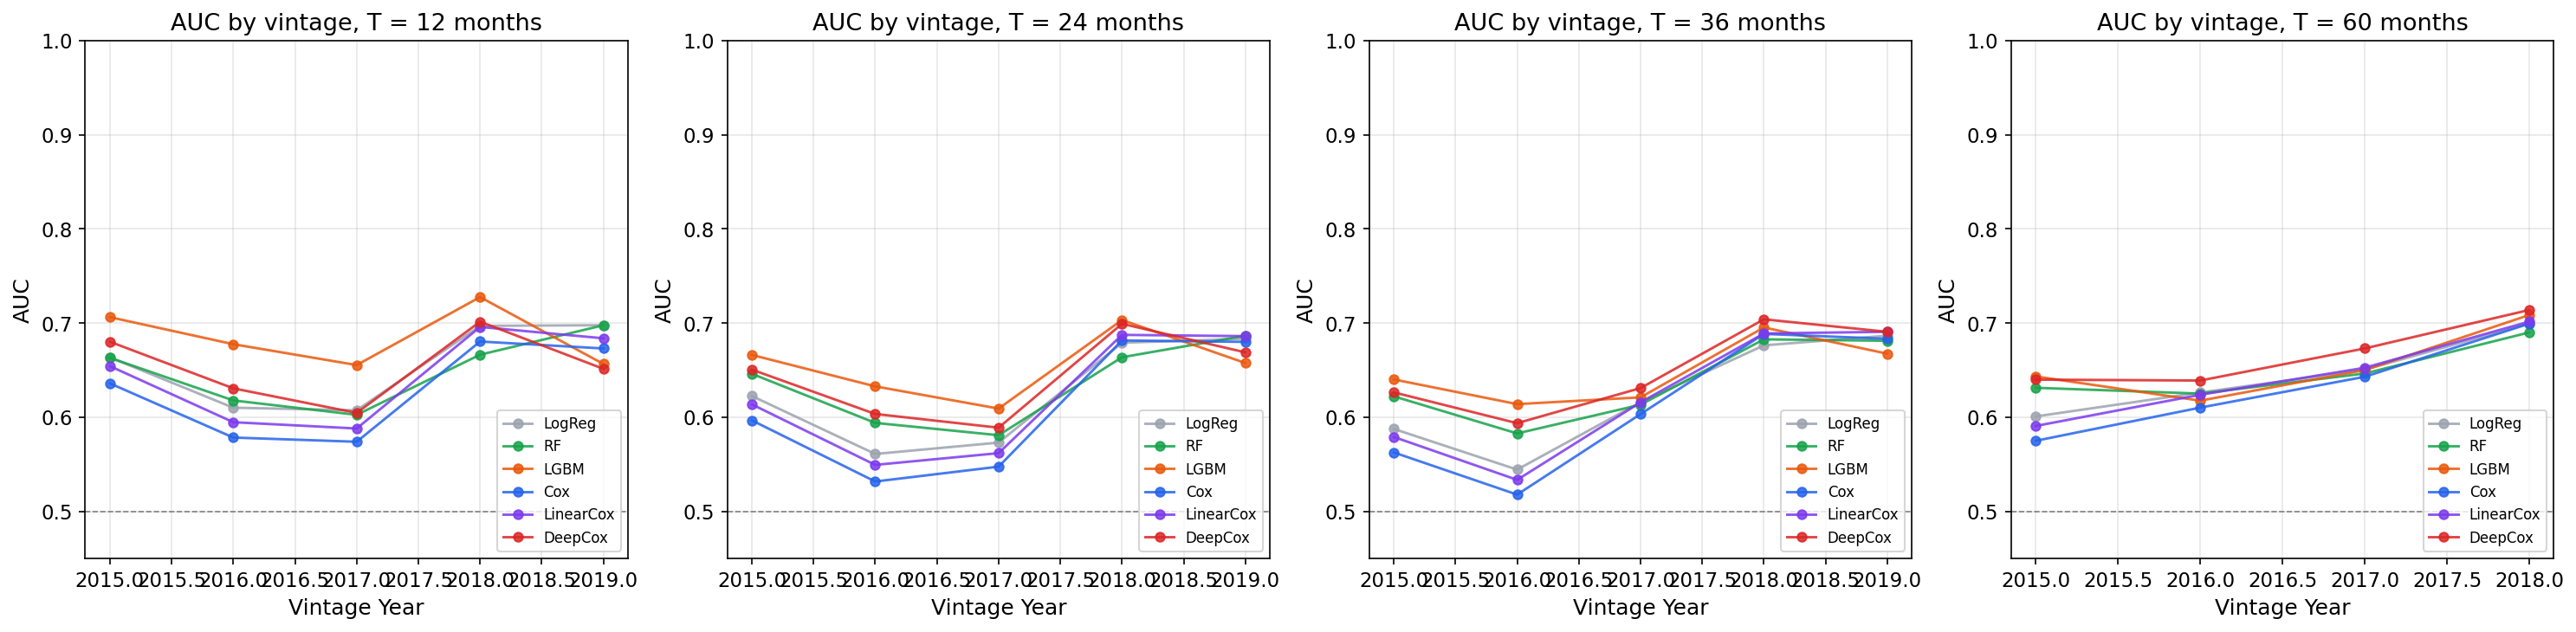

In [10]:
def plot_auc_by_vintage(metrics, models):
    sub = metrics[metrics["stratum_type"] == "vintage"].copy()
    if sub.empty:
        print("No vintage stratification found.")
        return
    sub["vintage"] = sub["stratum_value"].astype(int)
    horizons = sorted(sub["horizon"].unique())
    fig, axes = plt.subplots(1, len(horizons),
                              figsize=(5 * len(horizons), 5),
                              squeeze=False)
    axes = axes.ravel()
    for ax, T in zip(axes, horizons):
        for m in models:
            s = sub[(sub["model"] == m) & (sub["horizon"] == T)]                     .sort_values("vintage")
            if s.empty:
                continue
            ax.plot(s["vintage"], s["auc"], "o-",
                    color=MODEL_COLORS.get(m, "C0"), linewidth=1.4,
                    markersize=5, label=m, alpha=0.85)
        ax.set_xlabel("Vintage Year")
        ax.set_ylabel("AUC")
        ax.set_title(f"AUC by vintage, T = {T} months")
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
        ax.legend(fontsize=8, loc="lower right")
        ax.set_ylim(0.45, 1.0)
    fig.tight_layout()
    plt.show()

plot_auc_by_vintage(metrics, models_present)


## AUC by FICO bucket — credit-quality stratification

Borrower credit quality is one of the strongest predictors of prepayment
behavior (high-FICO borrowers refinance more readily; low-FICO borrowers
face friction). Stratifying by FICO surfaces whether a model has uniform
ranking quality or concentrates its skill in particular borrower
populations.

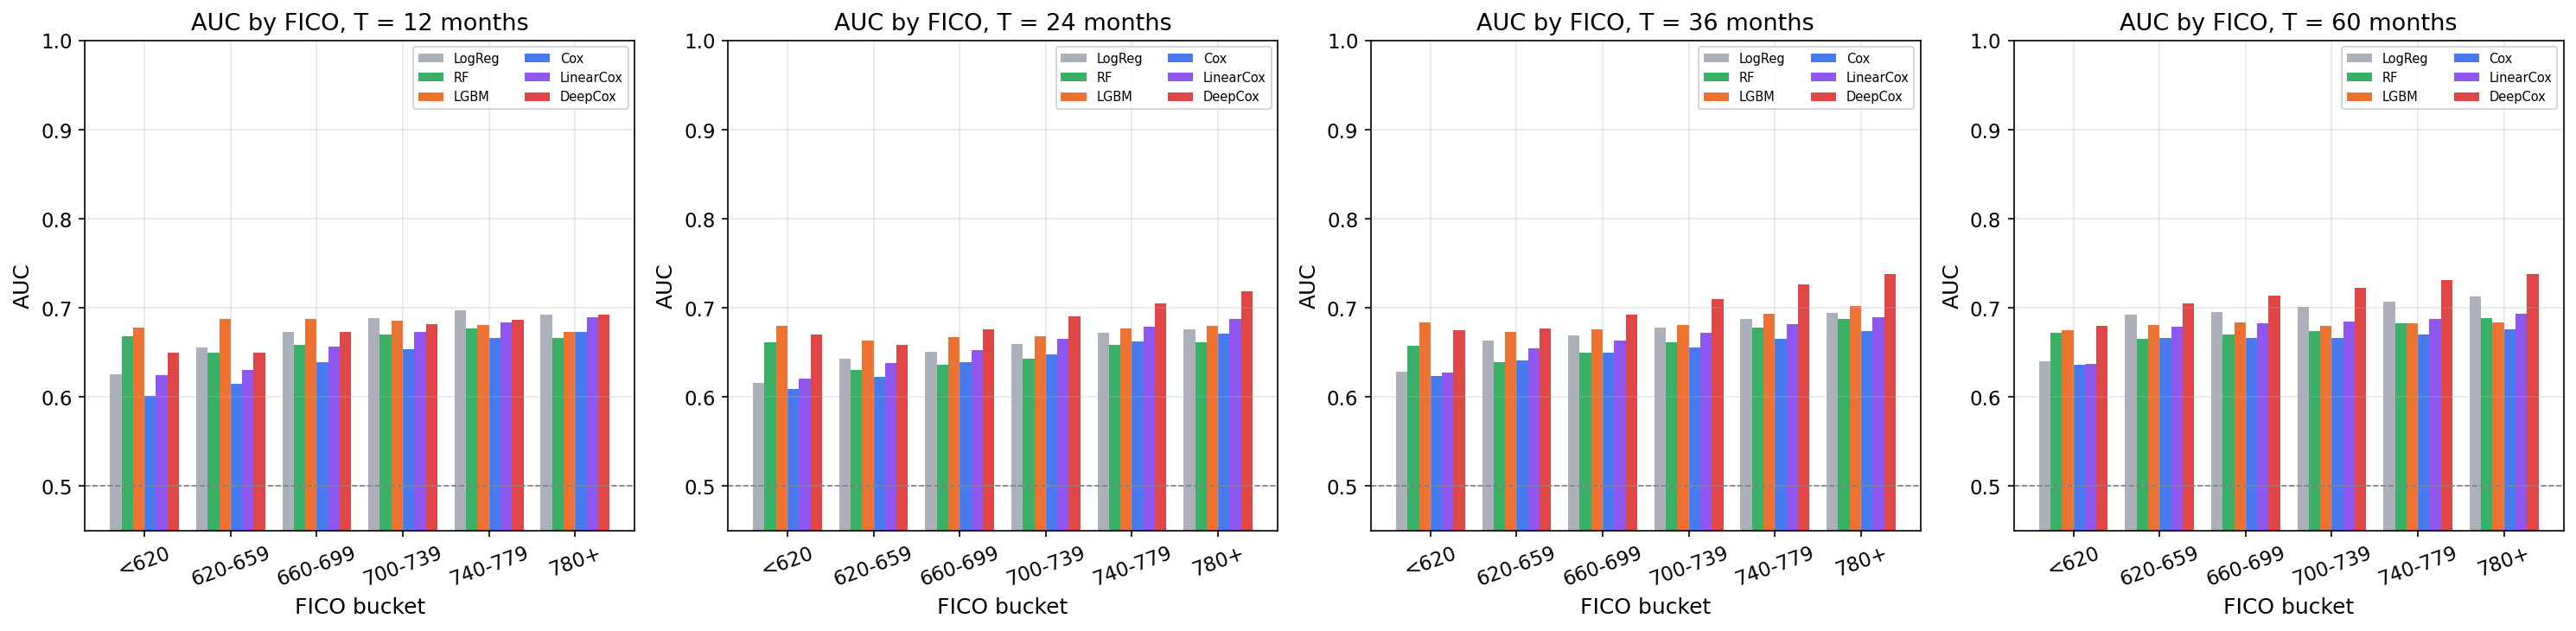

In [11]:
def plot_auc_by_fico(metrics, models):
    sub = metrics[metrics["stratum_type"] == "FICO"].copy()
    if sub.empty:
        print("No FICO stratification found.")
        return
    horizons = sorted(sub["horizon"].unique())
    fig, axes = plt.subplots(1, len(horizons),
                              figsize=(5 * len(horizons), 5),
                              squeeze=False)
    axes = axes.ravel()
    bucket_order = [b for b in FICO_BUCKETS
                    if b in sub["stratum_value"].unique()]
    for ax, T in zip(axes, horizons):
        width = 0.8 / max(len(models), 1)
        x = np.arange(len(bucket_order))
        for i, m in enumerate(models):
            s = sub[(sub["model"] == m) & (sub["horizon"] == T)]
            if s.empty:
                continue
            s = s.set_index("stratum_value")
            vals = [s.loc[b, "auc"] if b in s.index else np.nan
                    for b in bucket_order]
            offset = (i - (len(models) - 1) / 2) * width
            ax.bar(x + offset, vals, width,
                    color=MODEL_COLORS.get(m, "C0"), label=m, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(bucket_order, rotation=20)
        ax.set_xlabel("FICO bucket")
        ax.set_ylabel("AUC")
        ax.set_title(f"AUC by FICO, T = {T} months")
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
        ax.legend(fontsize=7, ncol=2)
        ax.set_ylim(0.45, 1.0)
    fig.tight_layout()
    plt.show()

plot_auc_by_fico(metrics, models_present)


## Top-decile lift

For investors who want to identify loans likely to remain current (or
likely to prepay) — the practical use case in Sadhwani et al. 2021 — what
matters isn't average AUC but how concentrated the top of the predicted
distribution is. The metric below: among the top 10% of test loans
ranked by predicted prepayment probability, what fraction actually prepaid
within horizon T? That fraction divided by the base prepayment rate gives
the **lift**: lift = 1.0 means random sorting, lift = 5.0 means the top
decile contains 5× the population's average prepay rate.

In [12]:
def compute_top_decile_lift(preds, models):
    rows = []
    for T in HORIZONS:
        target = preds[f"Target_T{T}"]
        valid = target.notna()
        if valid.sum() < 100:
            continue
        base_rate = float(target[valid].mean())
        for m in models:
            pcol = f"pred_{m}_T{T}"
            if pcol not in preds.columns:
                continue
            mask = valid & preds[pcol].notna()
            if mask.sum() < 100:
                continue
            sub = preds.loc[mask, [pcol, f"Target_T{T}"]].copy()
            cutoff = sub[pcol].quantile(0.9)
            top = sub[sub[pcol] >= cutoff]
            if len(top) == 0:
                continue
            top_rate = float(top[f"Target_T{T}"].mean())
            rows.append({
                "model": m, "horizon": T,
                "base_rate": base_rate,
                "top_decile_rate": top_rate,
                "lift": top_rate / base_rate if base_rate > 0 else np.nan,
                "n_top": int(len(top)),
            })
    return pd.DataFrame(rows)

lift_df = compute_top_decile_lift(predictions, models_present)
print(lift_df.round(4).to_string(index=False))


    model  horizon  base_rate  top_decile_rate   lift  n_top
   LogReg       12     0.1075           0.2726 2.5356  59636
       RF       12     0.1075           0.2351 2.1869  59636
     LGBM       12     0.1075           0.2761 2.5687  59636
      Cox       12     0.1075           0.2438 2.2679  59625
LinearCox       12     0.1075           0.2682 2.4952  59636
  DeepCox       12     0.1075           0.2715 2.5257  59636
   LogReg       24     0.2879           0.5459 1.8960  59551
       RF       24     0.2879           0.4828 1.6770  59551
     LGBM       24     0.2879           0.5850 2.0319  59551
      Cox       24     0.2879           0.5299 1.8405  59541
LinearCox       24     0.2879           0.5639 1.9586  59551
  DeepCox       24     0.2879           0.5988 2.0797  59551
   LogReg       36     0.4373           0.7417 1.6962  59102
       RF       36     0.4373           0.6966 1.5929  59102
     LGBM       36     0.4373           0.7719 1.7653  59102
      Cox       36     0

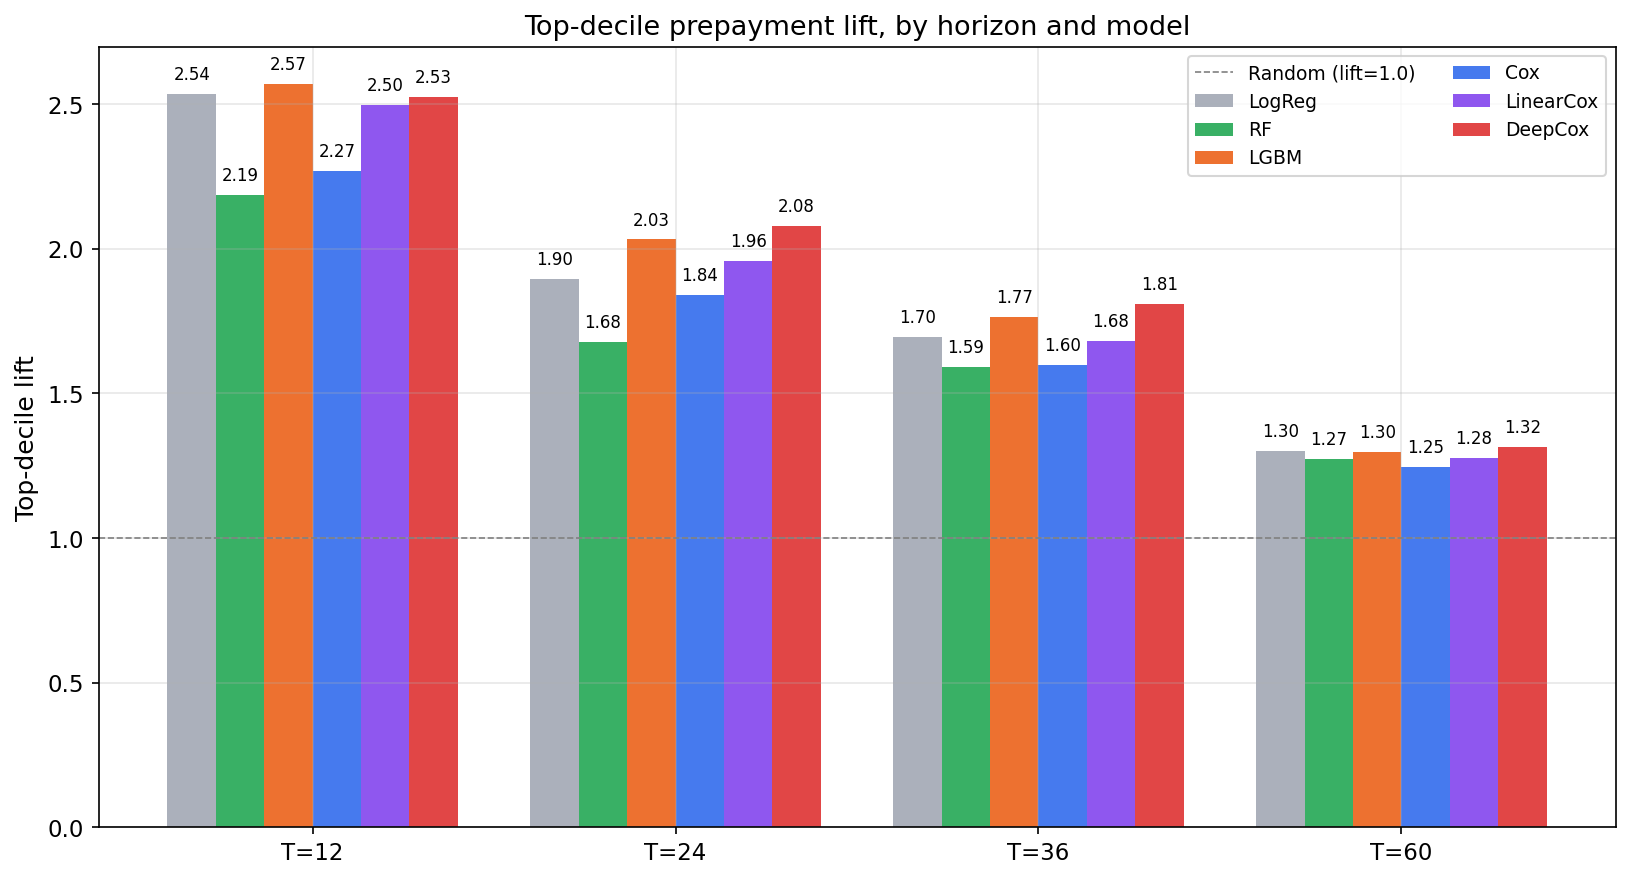

In [13]:
def plot_lift(lift_df, models):
    if lift_df.empty:
        print("No lift to plot.")
        return
    fig, ax = plt.subplots(figsize=(11, 6))
    width = 0.8 / max(len(models), 1)
    x = np.arange(len(HORIZONS))
    for i, m in enumerate(models):
        sub = lift_df[lift_df["model"] == m].set_index("horizon")
        if sub.empty:
            continue
        vals = [sub.loc[T, "lift"] if T in sub.index else np.nan
                for T in HORIZONS]
        offset = (i - (len(models) - 1) / 2) * width
        ax.bar(x + offset, vals, width,
                color=MODEL_COLORS.get(m, "C0"), label=m, alpha=0.85)
        for j, v in enumerate(vals):
            if pd.notna(v):
                ax.text(x[j] + offset, v + 0.05, f"{v:.2f}",
                        ha="center", fontsize=8)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8,
                label="Random (lift=1.0)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T={T}" for T in HORIZONS])
    ax.set_ylabel("Top-decile lift")
    ax.set_title("Top-decile prepayment lift, by horizon and model")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()
    plt.show()

plot_lift(lift_df, models_present)


## Score distributions — DeepCox vs others

If DeepCox concentrates probability mass differently than the linear or
tree-based models — bimodality, sharper tails, more conservative middle
— that's a signal that nonlinear interactions are reshaping the score
landscape, not just shifting it. We show one horizon (T=24) for clarity;
the patterns are similar across horizons.

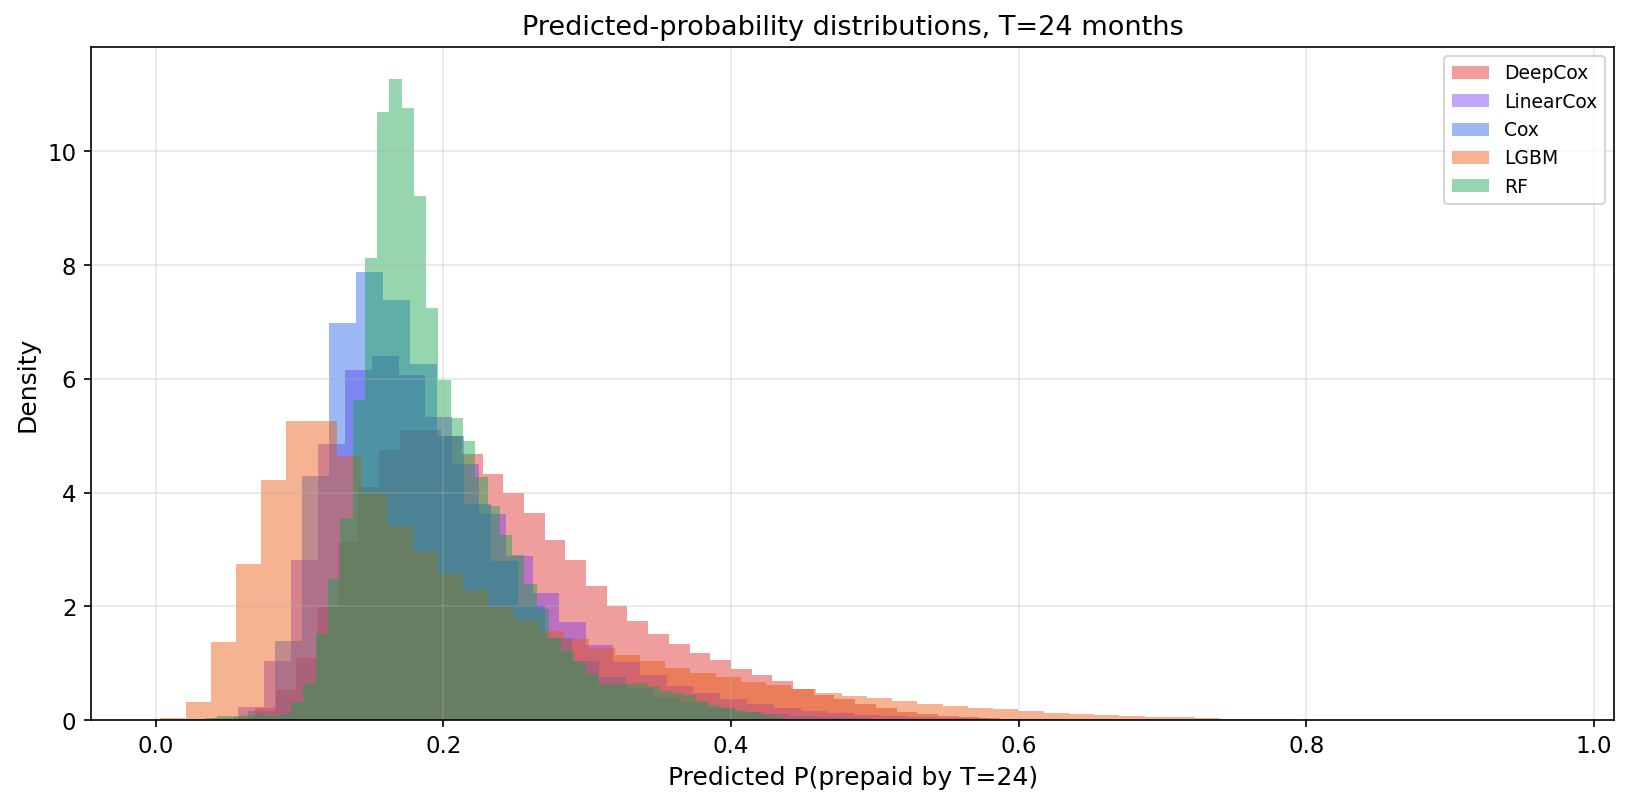

In [14]:
def plot_score_distributions(preds, models, T=24, key_models=None):
    if key_models is None:
        # Show the three most informative models if available
        for shortlist in (
            ["DeepCox", "LinearCox", "Cox", "LGBM", "RF"],
            ["DeepCox", "Cox", "LGBM"],
            ["DeepCox", "LinearCox"],
        ):
            inter = [m for m in shortlist if m in models]
            if len(inter) >= 2:
                key_models = inter
                break
    if not key_models:
        key_models = models
    fig, ax = plt.subplots(figsize=(11, 5.5))
    target_col = f"Target_T{T}"
    for m in key_models:
        pcol = f"pred_{m}_T{T}"
        if pcol not in preds.columns:
            continue
        valid = preds[target_col].notna() & preds[pcol].notna()
        if valid.sum() < 100:
            continue
        ax.hist(preds.loc[valid, pcol].values, bins=50, alpha=0.45,
                 color=MODEL_COLORS.get(m, "C0"), label=m, density=True)
    ax.set_xlabel(f"Predicted P(prepaid by T={T})")
    ax.set_ylabel("Density")
    ax.set_title(f"Predicted-probability distributions, T={T} months")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

plot_score_distributions(predictions, models_present)


## Summary table — all models, all horizons

In [15]:
overall = metrics[metrics["stratum_type"] == "all"].copy()
if len(overall):
    keys = ["model", "horizon"]
    rep = (overall[keys + ["auc", "brier", "log_loss", "accuracy",
                            "n", "n_events"]]
              .sort_values(keys).round(4))
    print(rep.to_string(index=False))


    model  horizon    auc  brier  log_loss  accuracy      n  n_events
      Cox       12 0.6635 0.0949    0.3359    0.8925 596248     64098
      Cox       24 0.6571 0.2048    0.6022    0.7126 595404    171419
      Cox       36 0.6596 0.2527    0.7027    0.5763 590916    258399
      Cox       60 0.6650 0.2659    0.7263    0.4795 531818    381311
  DeepCox       12 0.6837 0.0925    0.3240    0.8925 596352     64105
  DeepCox       24 0.7007 0.1885    0.5588    0.7171 595508    171452
  DeepCox       36 0.7211 0.2186    0.6269    0.6435 591019    258447
  DeepCox       60 0.7292 0.2007    0.5866    0.6915 531898    381377
     LGBM       12 0.6805 0.0916    0.3264    0.8928 596352     64105
     LGBM       24 0.6738 0.1941    0.5823    0.7257 595508    171452
     LGBM       36 0.6899 0.2343    0.6659    0.6287 591019    258447
     LGBM       60 0.6825 0.2503    0.6940    0.5454 531898    381377
LinearCox       12 0.6807 0.0935    0.3289    0.8925 596352     64105
LinearCox       24 0

## Reading guide & caveats

- **Mini-batch Cox approximation.** The Cox partial likelihood for
  Deep/Linear Cox is computed per minibatch; risk sets are batch-local.
  This is the standard pycox approach and the standard DeepSurv literature
  approach. A sensitivity check would re-run with `BATCH_SIZE` ∈ {512,
  1024, 2048} and confirm AUC differences are within the third decimal
  place. See `D_model_meta.json` for the actual batch size used.
- **Vintage-macro covariates.** Part B's macro covariates were joined at
  origination (`FirstPaymentDate`), so they capture the macro environment
  *into which* each cohort was originated, not the dynamic refinancing
  incentive *during* its life. Dynamic-rate prepayment models would need
  the loan-month panel, which is outside the memory budget here.
- **Cause-specific framing.** Targets default to `cause_specific`:
  competing terminations (default, third-party sale, REO) before the
  horizon are treated as right-censored, not as zeros. The `binary` mode
  treats them as zeros and tends to inflate AUC slightly because it
  introduces "easy" negatives. Compare the two modes if it matters.
- **Train/val/test split.** Train: vintages ≤ 2014. Test: 2015–2019.
  Validation: 10% random carve from train, used only for early stopping.
  The exact partition is reproducible from `canonical_split.parquet`
  (Parts C and D both consume it) and `canonical_split_with_val.parquet`
  (Part D's val carve).
- **Standardization.** Scaler stats fit only on the inner-train portion;
  val and test transformed with those stats. Encoders (medians, top-K
  categorical levels) likewise fit only on the Part C training set; both
  C and D use the same fitted encoders for fair comparison.
- **Right-censoring at T=60.** A meaningful fraction of test loans hasn't
  reached the 60-month horizon yet; these are NaN in `Target_T60` and
  contribute zero rows to the T=60 metrics. AUCs at T=60 are therefore
  computed on a smaller, slightly different slice of the test universe
  than at T=12. The `n` column in the summary table makes this explicit.
